In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [2]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s13/experiments/distillation-layerwise/run2-policies"

In [4]:
def read_data(
    teacher,
    student,
    basis_name,
    lambda_task,
    lambda_kd,
    lambda_layer,    
    training_size,
    verbose=False
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": lambda_layer},
            {"config.policy": basis_name},
            {"config.training_size": training_size},

        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
        
        for i, (val_acc, val_agreement) in enumerate(
            zip(
                run.summary["arr_metrics"]["val_acc"],
                run.summary["arr_metrics"]["val_agreement"],
            )
        ):
            rows.append(
                dict(
                    seed=seed, 
                    epoch=i,
                    val_acc=val_acc, 
                    val_agreement=val_agreement,
                    teacher_acc=run.summary["teacher_acc"]
                )
            )

    
    df = pd.DataFrame(rows)
        
    df = df.groupby(by="epoch").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "teacher_acc": ["mean", "std"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18compr2",
    lambda_task=0.0,
    lambda_kd=1.0,
    lambda_layer=0.0,
    basis_name="basis:prca-sortabs",
    training_size=1.0,
    verbose=True
)

summary

we have 20 runs
df.shape: (101, 9)


epoch   val_acc                 val_agreement                 teacher_acc  \
               mean       std count          mean       std count        mean   
0       0  0.211328  0.028953    20      0.204687  0.032321    20      0.8716   
1       1  0.472200  0.085073    20      0.478900  0.087203    20      0.8716   
2       2  0.509800  0.081993    20      0.517000  0.081524    20      0.8716   
3       3  0.550900  0.112823    20      0.558100  0.107610    20      0.8716   
4       4  0.582100  0.104377    20      0.587700  0.102407    20      0.8716   
..    ...       ...       ...   ...           ...       ...   ...         ...   
96     96  0.785000  0.099427    20      0.790100  0.094309    20      0.8716   
97     97  0.787600  0.096384    20      0.792000  0.095543    20      0.8716   
98     98  0.787300  0.103997    20      0.793000  0.098762    20      0.8716   
99     99  0.785100  0.099030    20      0.791100  0.095064    20      0.8716   
100   100  0.782400  0.097723    20      0.787900  0.096733    20      0.8716   

               
          std  
0    0.077616  
1    0.077616  
2    0.077616  
3    0.077616  
4    0.077616  
..        ...  
96   0.077616  
97   0.077616  
98   0.077616  
99   0.077616  
100  0.077616  

[101 rows x 9 columns]

# Viz Distillation Over 20 Classes

## Comparison on `cifar100-resnet18-wb15`

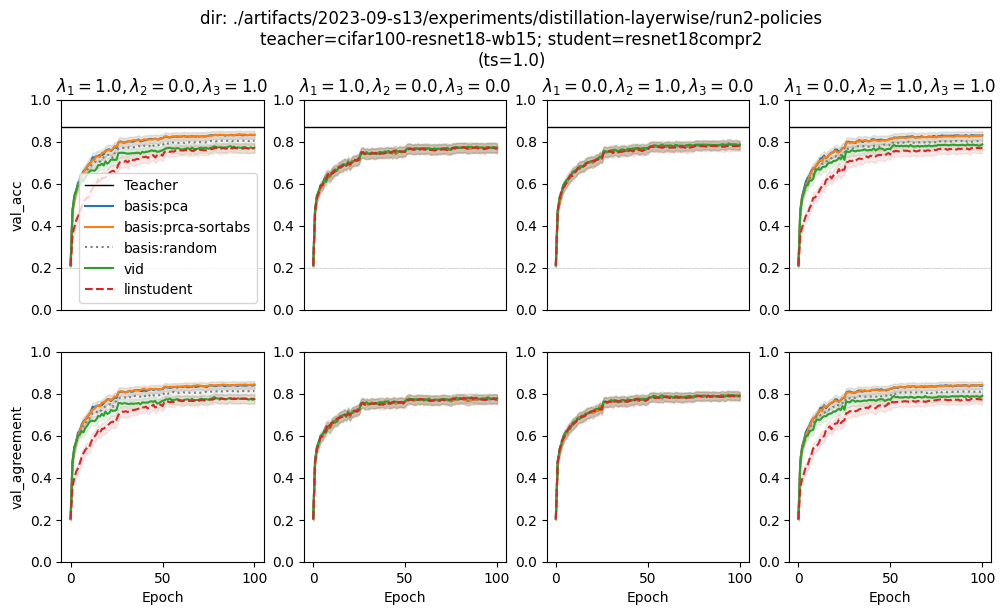

In [5]:
def ls(basis_name):
    if "random" in basis_name:
        return ":"
    elif basis_name == "linstudent":
        return "--"
    else:
        return "-"
    
def color(basis_name):
    if "random" in basis_name:
        return "gray"
    else:
        return None
    
def viz_distillation(teacher, student, arr_lambdas, training_size):
        
    basis_names = [ 
        "basis:pca",
        "basis:prca-sortabs",
        "basis:random",
        "vid",
        "linstudent"
    ]
        
    ncols = len(arr_lambdas)
    nrows = 2
    
    plt.figure(figsize=(3*ncols, 3*2))
    
    plt.suptitle(
        "\n".join([
            f"dir: {EXPERIMENT_GROUP}",
            f"teacher={teacher}; student={student}",
            f"(ts={training_size})"
        ]),
        y=1.03
    )
    
    for lix, (lambda_task, lambda_kd, lambda_layer) in enumerate(arr_lambdas):
        for cix, col in enumerate(["val_acc", "val_agreement"]):
            plt.subplot(nrows, ncols, cix * ncols + lix + 1)
            plt.ylim([0, 1])

            for bix, basis_name in enumerate(basis_names):
                
                df = read_data(
                    teacher=teacher,
                    student=student,

                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,
                    lambda_layer=lambda_layer,

                    basis_name=basis_name,
                    training_size=training_size,
                    verbose=False
                )
                
                
                if cix == 0:
                    plt.title(f"$\lambda_1={lambda_task},\lambda_2={lambda_kd},\lambda_3={lambda_layer}$")
                    plt.xticks([])
                    teacher_acc = df["teacher_acc"]["mean"][0]
                    plt.axhline(0.2, ls="--", lw=0.5, color="lightgray")
                    if bix == 0:
                        plt.axhline(
                            teacher_acc,
                            label="Teacher",
                            color="k",
                            lw=1
                        )
                    
                epochs = df["epoch"]
                metric_mean = df[col]["mean"]
                metric_stderr = df[col]["std"] / (df[col]["count"] ** 0.5)
                plt.plot(
                    epochs,
                    metric_mean,
                    label=basis_name,
                    ls=ls(basis_name),
                    color=color(basis_name)
                )
                plt.fill_between(
                    epochs,
                    metric_mean-metric_stderr,
                    metric_mean+metric_stderr,
                    color=plt.gca().lines[-1].get_color(),
                    alpha=0.1
                )
    

                
                    
            if lix == 0:
                plt.ylabel(col)
                
                if cix == 0:
                    plt.legend()
                    
            if cix == 1:
                plt.xlabel("Epoch")

viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18compr2",
    training_size=1.0,
    arr_lambdas=[
      (1.0, 0.0, 1.0),
      (1.0, 0.0, 0.0),
      (0.0, 1.0, 0.0),
      (0.0, 1.0, 1.0),
    ]
) 

### on student=`resnet18customized`

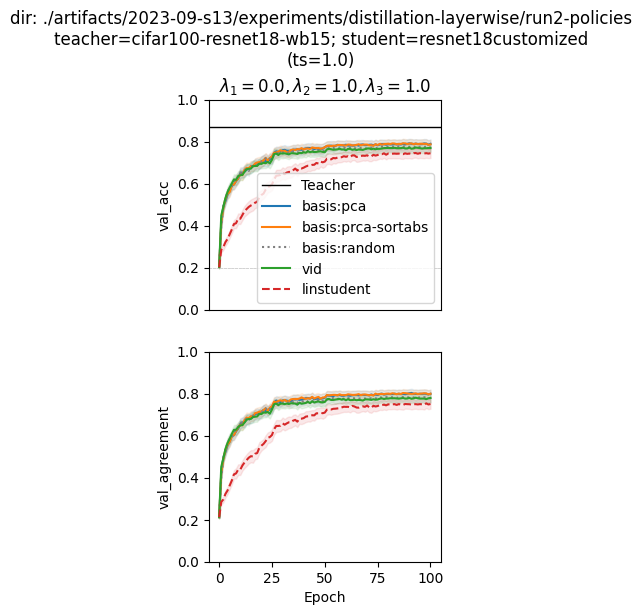

In [6]:
viz_distillation(
    teacher="cifar100-resnet18-wb15",
    student="resnet18customized",
    training_size=1.0,
    arr_lambdas=[
      (0.0, 1.0, 1.0),
    ]
) 

## Comparison on `cifar100-resnet18-p1`

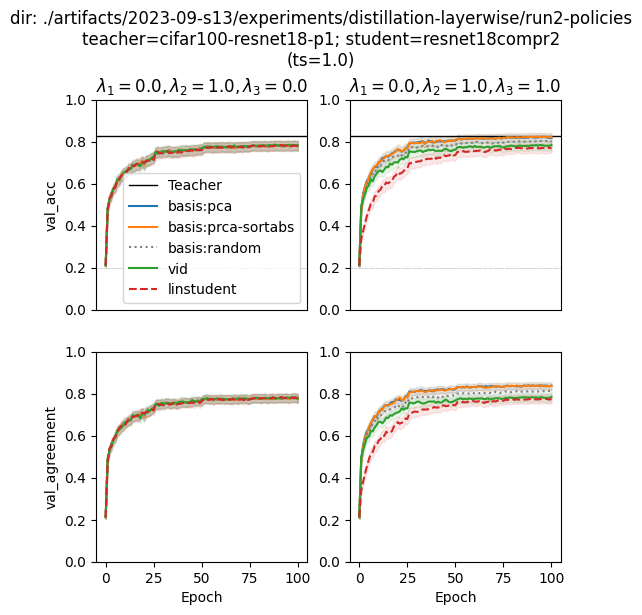

In [7]:
viz_distillation(
    teacher = "cifar100-resnet18-p1",
    student = "resnet18compr2",
    training_size=1.0,
    arr_lambdas=[
      (0.0, 1.0, 0.0),
      (0.0, 1.0, 1.0),
    ]
) 

### Across different choices of student networks

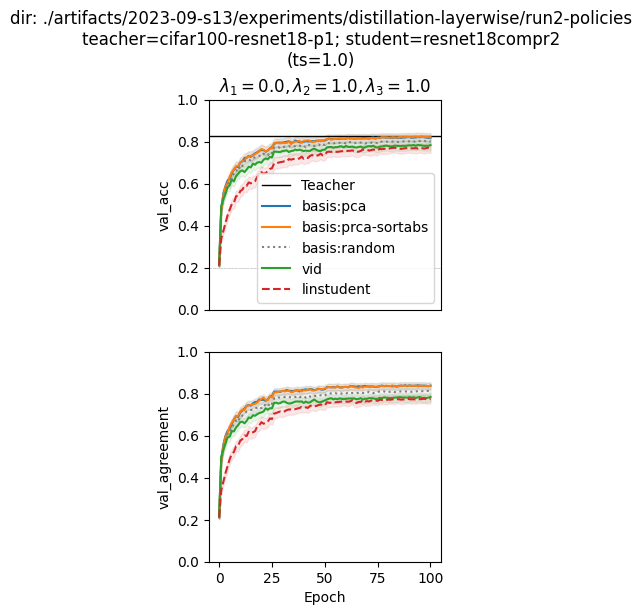

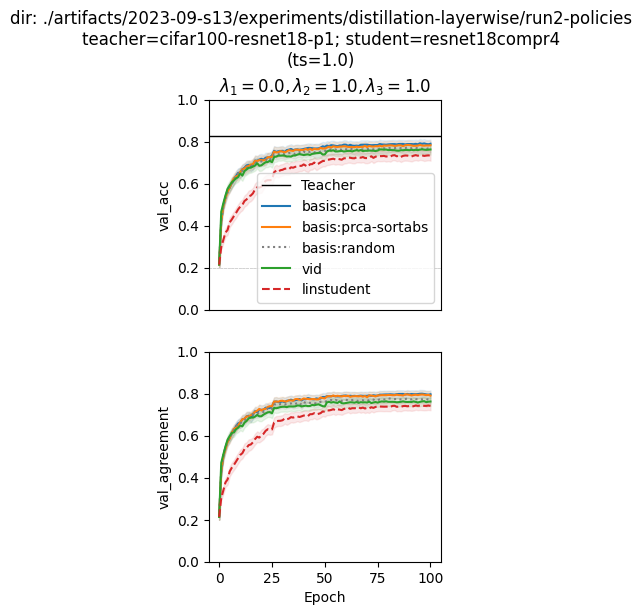

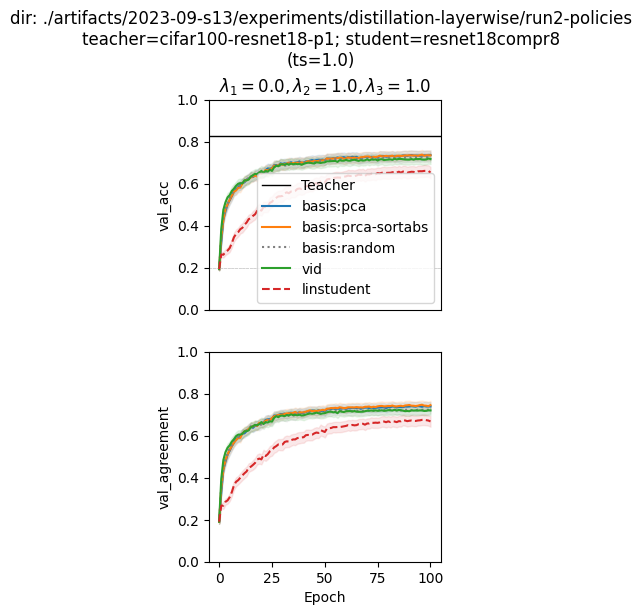

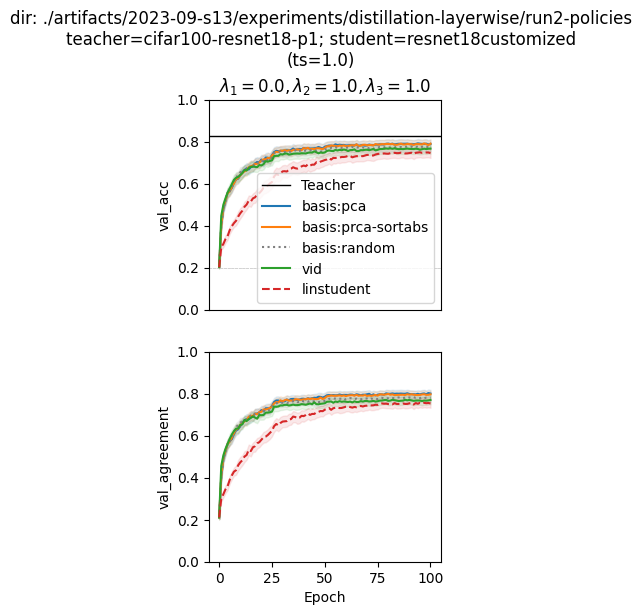

In [8]:
for student in ["resnet18compr2", "resnet18compr4", "resnet18compr8", "resnet18customized"]:    
    viz_distillation(
        teacher="cifar100-resnet18-p1",
        student=student,
        training_size=1.0,
        arr_lambdas=[
          (0.0, 1.0, 1.0),
        ]
    ) 

# Summary

Setup:
$$
 \lambda_1 \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer}
$$

Aims: 
- investigate whether layerwise loss helps improve performance
- investigate whether the effecacy of the task and KD loss.


Conclusion: 
- Without layer loss, using only $\ell_\text{KD}$ seems to be better than using the $\ell_\text{task}$.
- For $\ell_\text{KD}$ and $\ell_\text{task}$, combining with $\ell_\text{layer}$ improve performance when using orthogonal bases, `vid`, and `linstudent`.
- We do NOT observe any benefit from PRCA.

Caveats:
- this results could be confounded from
    1. the weighting between $\lambda$'s.
    2. training configuration

Follow-up:
- why do we see the benefit of `prca-sortabs`? 
- why does `random` perform better than `vid`?
    - could we reproduce this from other opensource? 
- why does `agreement` look similar to `accuracy`? 
    - the two curves are too similar.
    - Desptie the fact that `val_agreement` is low, `train_agreement` is actual not that low.
- why could NOT we reach teacher acc?
    - is it because, by splitting subclasses, we do NOT use all the training samples?
        - if this is the case, it is a challenge of subtask distillation in general.
- ~~why does `learnlin` perform poorly with $\ell_\text{layer}$?~~
    - the improved version of `learnlin` is `linstudent` which transforms student's features.
    